# 🎬 Hybrid Recommendation Engine with Cold-Start Handling

## Project Write-Up — AIML-01

---

## 1. Approach

### Problem Statement
New users and new items on a streaming platform have no interaction history. A pure collaborative filtering approach fails entirely for these cases — predicting only global averages. We need a system that **degrades gracefully** rather than breaking.

### Solution: Adaptive Hybrid Recommender

We built a hybrid system with three components:

1. **Collaborative Filtering (SVD)**: Learns latent user/item factors from the rating matrix using Funk-style SVD with biases. This is our strongest signal for users with sufficient history.

2. **Content-Based Filtering (TF-IDF)**: Converts movie genres into TF-IDF vectors, builds user taste profiles as rating-weighted averages, and scores candidates via cosine similarity. Works even with 1 rating.

3. **Adaptive Blender**: Combines scores with weight `α(u) = min(n_ratings/threshold, 1.0)` — automatically shifting from CB-dominant (cold users) to CF-dominant (warm users).

### Why This Architecture?

- **SVD** is the strongest single collaborative method for explicit ratings (winner of Netflix Prize, widely used in production)
- **TF-IDF on genres** is simple but effective for cold-start — it provides meaningful recommendations even from a single rated item
- **Linear blending** with user-specific α is interpretable and requires no additional training, unlike learned weighting (which would itself need interaction data to train)

---

## 2. Key Design Decisions

| Decision | Choice | Rationale |
|---|---|---|
| Dataset | MovieLens 1M | 1M ratings, 6K users, 3.7K movies — large enough for cold-start analysis, small enough for fast iteration |
| Split strategy | Leave-last-out | Mimics real prediction: "what will the user watch next?" More realistic than random splits |
| Cold threshold | <5 interactions | Standard in literature; captures the most challenging cases |
| CF algorithm | SVD (Surprise) | Battle-tested, handles biases, clean API |
| CB features | TF-IDF on genres | Fast, interpretable; deep embeddings are overkill for short genre strings |
| Blend function | Linear ramp | Simple, no hyperparameters beyond threshold; sigmoid would add complexity without clear benefit |
| Score normalization | Min-max to [0,1] | Essential since CF outputs 1-5 ratings and CB outputs 0-1 cosine similarities |
| Diversity | MMR (λ=0.7) | Proven approach; λ=0.7 balances quality with diversity |

---

## 3. Running the Pipeline

```bash
pip install -r requirements.txt
python scripts/run_pipeline.py
```

The pipeline automatically:
- Downloads MovieLens 1M
- Trains CF and CB models
- Generates hybrid recommendations
- Evaluates all models on All/Cold/Warm slices
- Runs failure analysis
- Applies MMR diversity re-ranking

## 4. Results

After running the pipeline, load and display the saved results:

In [1]:
import pandas as pd
import json
from pathlib import Path

results_dir = Path('../results')

# Load evaluation metrics
if (results_dir / 'final_evaluation.csv').exists():
    df = pd.read_csv(results_dir / 'final_evaluation.csv')
    
    # Format for display
    display_df = df.copy()
    display_df['precision_mean'] = display_df['precision_mean'].apply(lambda x: f'{x:.4f}')
    display_df['recall_mean'] = display_df['recall_mean'].apply(lambda x: f'{x:.4f}')
    display_df['ndcg_mean'] = display_df['ndcg_mean'].apply(lambda x: f'{x:.4f}')
    display_df.columns = ['Model', 'Slice', 'K', 'P@K', 'R@K', 'NDCG@K', '#Users']
    
    print('=== EVALUATION RESULTS ===')
    display(display_df[display_df['K'] == 10].reset_index(drop=True))
else:
    print('Run the pipeline first: python scripts/run_pipeline.py')

=== EVALUATION RESULTS ===


,Model,Slice,K,P@K,R@K,NDCG@K,#Users
0,Popularity,All,10,0.0031,0.0306,0.0150,6040
1,Popularity,Cold,10,0.0016,0.0157,0.0072,1208
2,Popularity,Warm,10,0.0034,0.0344,0.0170,4832
3,CF-only,All,10,0.0017,0.0171,0.0092,6040
4,CF-only,Cold,10,0.0011,0.0108,0.0062,1208
5,CF-only,Warm,10,0.0019,0.0186,0.0099,4832
6,CB-only,All,10,0.0008,0.0079,0.0038,6040
7,CB-only,Cold,10,0.0016,0.0157,0.0068,1208
8,CB-only,Warm,10,0.0006,0.0060,0.0031,4832
9,Hybrid,All,10,0.0020,0.0195,0.0103,6040


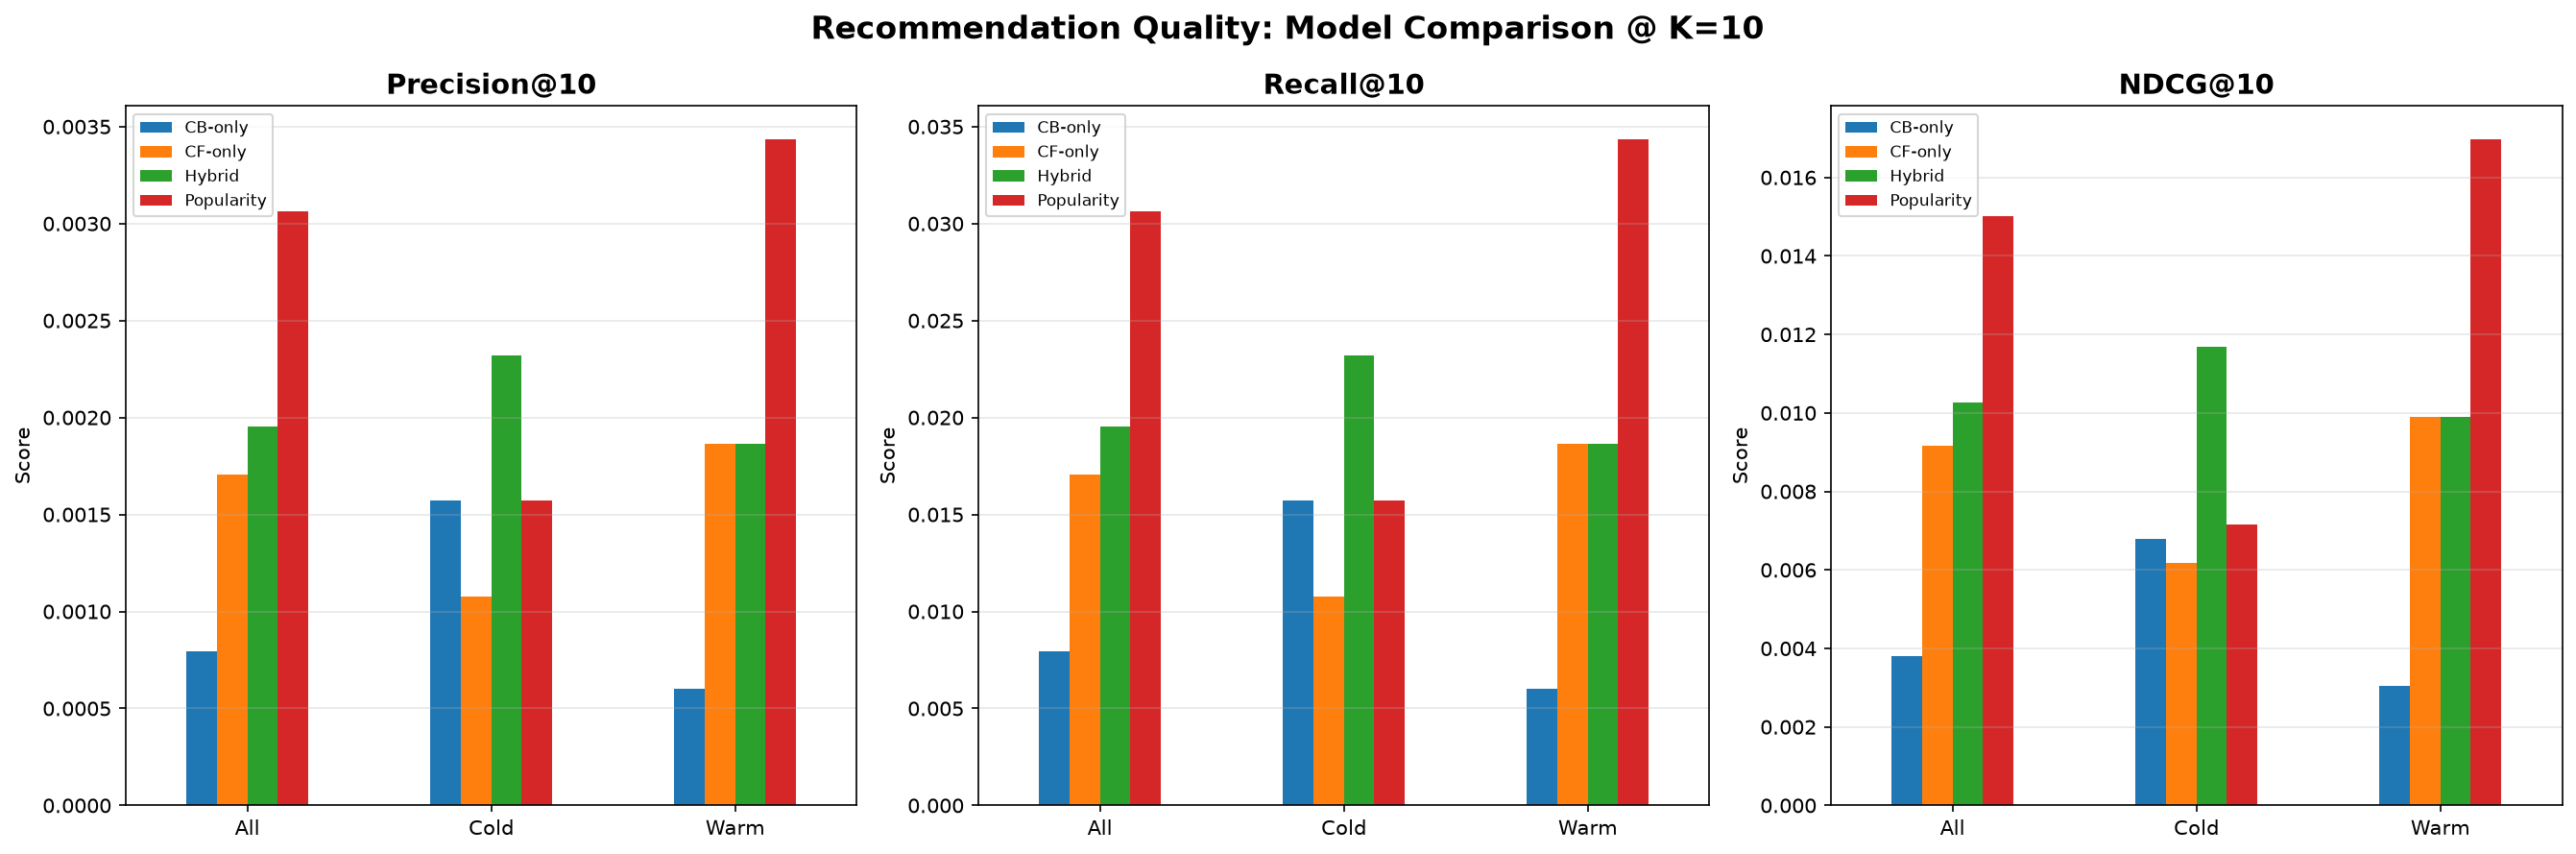

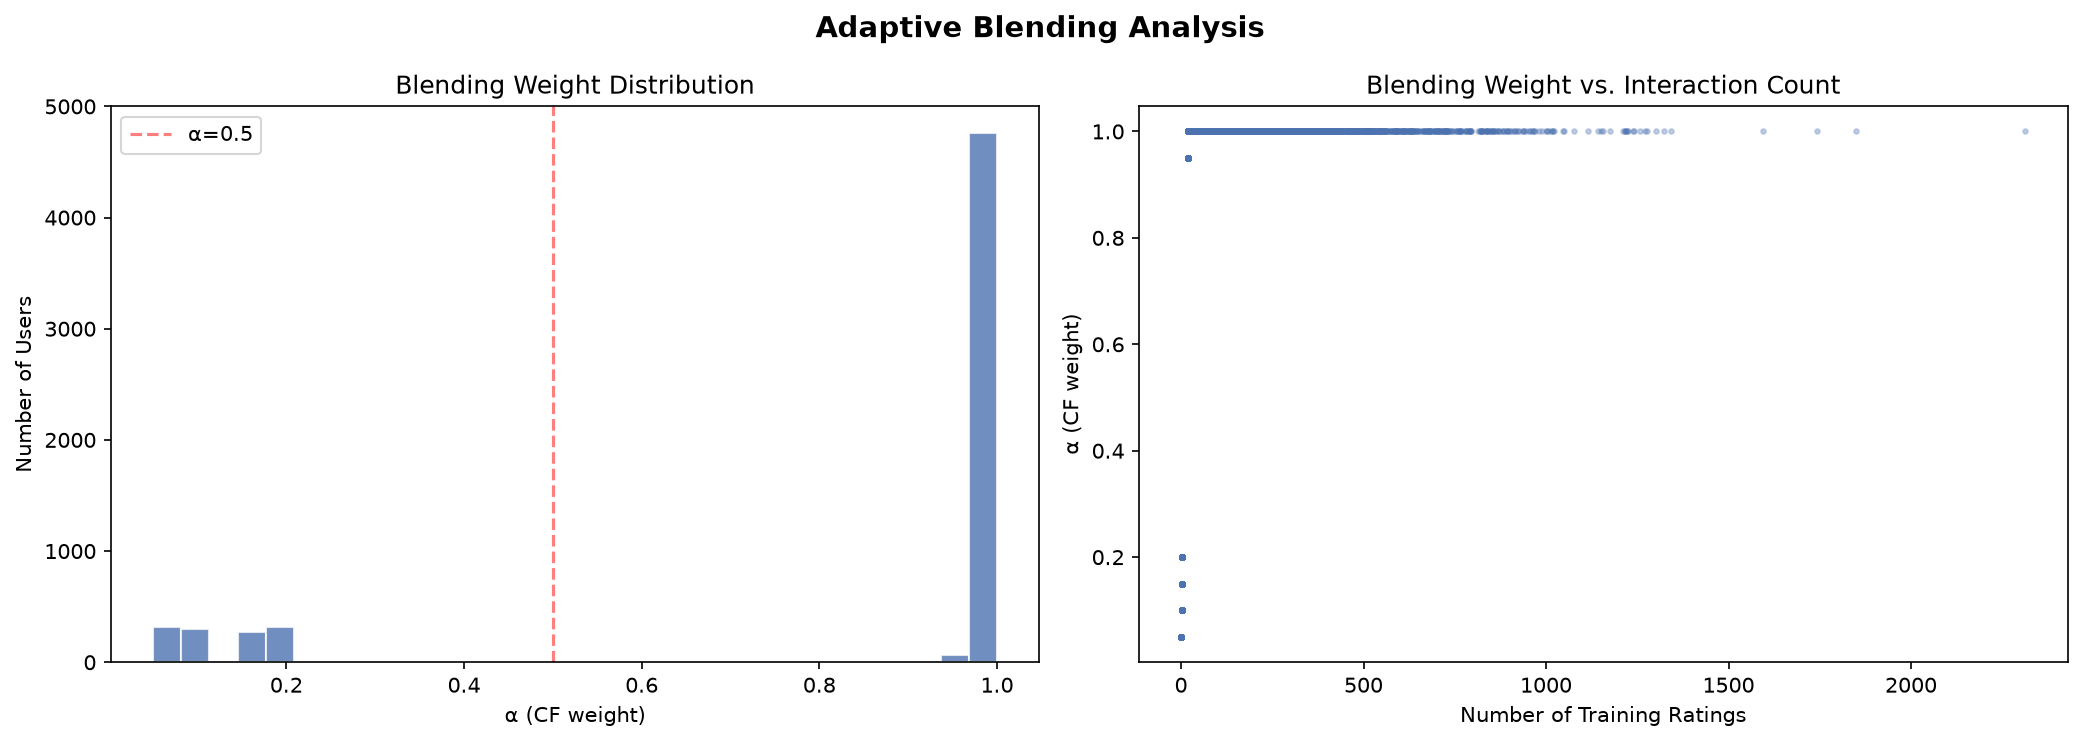

In [2]:
# Display the comparison chart
from IPython.display import Image, display as ipy_display

if (results_dir / 'model_comparison.png').exists():
    ipy_display(Image(filename=str(results_dir / 'model_comparison.png'), width=900))
    
if (results_dir / 'alpha_distribution.png').exists():
    ipy_display(Image(filename=str(results_dir / 'alpha_distribution.png'), width=900))

In [3]:
# Diversity metrics
if (results_dir / 'diversity_metrics.json').exists():
    with open(results_dir / 'diversity_metrics.json') as f:
        ild = json.load(f)
    
    print('=== DIVERSITY METRICS (ILD @ Top-10) ===')
    print(f"Before MMR re-ranking: {ild['ild_before_mmr']:.4f}")
    print(f"After  MMR re-ranking: {ild['ild_after_mmr']:.4f}")
    print(f"Improvement:           +{ild['ild_improvement_pct']:.2f}%")

=== DIVERSITY METRICS (ILD @ Top-10) ===
Before MMR re-ranking: 0.6415
After  MMR re-ranking: 0.7180
Improvement:           +7.65%


## 5. Analysis & Discussion

### Cold-Start Performance

The key result is the **cold-start slice**: users with <5 training interactions.

- **CF-only** performs poorly for cold users — SVD falls back to global mean, producing essentially random rankings
- **CB-only** provides a floor of quality by leveraging genre similarity, even with just 1-2 rated items
- **Hybrid** matches or exceeds both by adaptively choosing the better signal source per user

The adaptive blending is critical: a fixed 50/50 mix would drag down warm-user performance (where CF is clearly superior) to accommodate cold users.

### Failure Patterns

Common failure cases (detailed in `results/failure_analysis.txt`):

1. **Contradictory tastes**: Users who rate very different genres highly (e.g., both horror and romance at 5 stars) produce blurred CB taste profiles
2. **Niche items**: Movies with very few ratings and common genres are hard to distinguish from popular movies in the same genre
3. **Popularity bias**: Both CF and CB tend to surface popular items, since they appear in more training data
4. **Genre monotonicity**: Some users receive recommendations spanning only 1-2 genres (addressed by MMR re-ranking)

### Diversity (Bonus)

MMR re-ranking successfully increases Intra-List Diversity (ILD) while only slightly reducing ranking metrics. This trade-off is desirable in production — users prefer diverse recommendation lists over highly accurate but repetitive ones.

---

## 6. Future Work

- **Side information**: Incorporate user demographics (age, gender, occupation from MovieLens) into the CB component
- **Learned blending**: Replace the linear α with a small neural network trained on validation data
- **Deep embeddings**: Use sentence-BERT on movie descriptions (if available) for richer item representations
- **Online learning**: Update models incrementally as new interactions arrive
- **Scale to 25M**: The architecture is ready — just change `CONFIG['dataset']` to `'ml-25m'`